<p> <center><img src="img.jpg" style="height:200px"> </p>

<hr style="border-width:2px;border-color:#AAD">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Features Engineering </h2></center>
<hr style="border-width:2px;border-color:#AAD">

# I - Chargement des données PACA

Cette étape consiste à charger le fichier **"paca_meteo_energie.csv"** contenant les données météorologiques et radiatives régionales pour la région PACA avec une résolution temporelle de **30 minutes**.

Les variables disponibles dans ce jeu de données comprennent notamment:

- **`azimuth`** : azimut solaire (en degrés), indiquant la direction du soleil par rapport au nord (0–360° selon la convention).  
- **`altitude`** : altitude solaire (en degrés), représentant l'élévation du soleil au-dessus de l'horizon (valeurs négatives durant la nuit).  
- **`Temperature`** *(souvent `T2M`)* : température de l'air à 2 mètres du sol (en °C ou en K selon la source ; une vérification des unités est nécessaire).  
- **`GHI`** (*Global Horizontal Irradiance*) : irradiance globale reçue sur un plan horizontal (composantes directe et diffuse) exprimée en Wh/m².  
- **`BHI`** (*Beam Horizontal Irradiance*) : composante directe du rayonnement solaire projetée sur le plan horizontal (Wh/m²).  
- **`DHI`** (*Diffuse Horizontal Irradiance*) : composante diffuse du rayonnement solaire reçue sur un plan horizontal (Wh/m²).  
- **`BNI`** (*Beam Normal Irradiance*) : irradiance directe normale, reçue sur un plan perpendiculaire aux rayons solaires (Wh/m²).  
- **`Vitesse_Vent`** *(souvent `V2M`)* : vitesse du vent mesurée à 2 mètres du sol (m/s).  
- **`Nebulosite`** *(souvent `cloud_AMT`)* : nébulosité ou fraction de couverture nuageuse (exprimée selon les produits en fraction, pourcentage ou indice adimensionnel).  
- **`Humidite`** : humidité de l'air (généralement humidité relative en %, ou humidité spécifique selon la source).  
- **`Clear_sky_GHI`** : irradiance globale horizontale en conditions de ciel clair, utilisée comme référence théorique sans nuages (Wh/m²).  
- **`Clear_sky_BHI`** : composante directe horizontale en conditions de ciel clair (Wh/m²).  
- **`Clear_sky_DHI`** : composante diffuse horizontale en conditions de ciel clair (Wh/m²).  
- **`Clear_sky_BNI`** : irradiance directe normale en conditions de ciel clair (Wh/m²).  
- **`TOA`** (*Top Of Atmosphere*) : rayonnement solaire incident au sommet de l'atmosphère (Wh/m²), utilisé pour le contrôle de cohérence et la normalisation des séries.



Nous commencons par importer les librairies nécessaires pour manipuler nos données :

In [1]:
# Gestion des chemins
from pathlib import Path

# Données et calculs
import pandas as pd
import numpy as np

# Dataviz
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Analyse des variables
from sklearn.feature_selection import VarianceThreshold

# Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Sauvegarder les pipelines
import cloudpickle


On récupère les données collectées aux étapes précédentes :

In [24]:
# Chemin vers le répertoire de données d'entrée
input_path = Path('../data/local_data/input/')

# Chemin vers le répertoire de résultats temporaires
temp_path = Path('../data/local_data/temp/')

# Chemin vers le répertoire de résultats finaux
output_path = Path('../data/local_data/output')

# Chemin du dataset de production
input_datasets = output_path / 'raw_2020_2025.csv'

# Chemin du dataset des communes sélectionnées 
communes = output_path / 'best_communes_geo_energy.csv'


In [25]:
# On récupère le dataset raw_2020_2025.csv
df = pd.read_csv(
    input_datasets, 
    index_col='datetime_utc', 
    parse_dates=True)

# Ainsi que les données concernant les cinq points significatifs
df_communes = pd.read_csv(communes)


In [27]:
# Extraction de la liste des préfixes des points d'intérêts :
villes = list(df_communes['prefix'])
print("Préfixes des points d'intérêts :", villes)

# Extraction de la base du nom des variables appartenant aux points d'intérêts
var_5pts = []
# Comme tous les points d'intérêts ont exactement les même colonnes les concernant,
# on fait une recherche des noms concernant la ville de Bras (villes[0])
for col in df.columns : # Pour toutes les colonnes de X
    if col[:3] == villes[0]: # On cherche celles commencant par le préfixe 'bra'
        var_5pts.append(col[4:]) # On ajoute le nom de la colonne (moins le préfixe de la ville)
        # On a ici tiré parti du fait que tous les préfixes sont codés sur 3 lettres    
print("\nVariables disponible pour chaque points d'intérets :")
for var in var_5pts:
    print(f'\t{var}')
    

Préfixes des points d'intérêts : ['cru', 'sel', 'svt', 'bra', 'eyg']

Variables disponible pour chaque points d'intérets :
	altitude
	azimuth
	bhi
	bni
	clear_sky_bhi
	clear_sky_bni
	clear_sky_dhi
	clear_sky_ghi
	dhi
	ghi
	humidite
	nebulosite
	reliability
	temperature
	toa
	vitesse_vent


In [26]:
display(df.head())

,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,svt_ghi,svt_humidite,svt_nebulosite,svt_reliability,svt_temperature,svt_toa,svt_vitesse_vent,target,tch_solaire,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,-68.046190,335.241040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,57.600,29.440,1.0,9.30,0.0,1.190,0.0,0.0,0.0
2019-12-31 23:30:00+00:00,-69.500739,353.945722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,56.165,24.785,1.0,9.48,0.0,1.075,0.0,0.0,0.0
2020-01-01 00:00:00+00:00,-69.141123,13.536657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,54.730,20.130,1.0,9.66,0.0,0.960,0.0,0.0,0.0
2020-01-01 00:30:00+00:00,-67.054165,31.240402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,54.250,10.340,1.0,9.72,0.0,0.850,0.0,0.0,0.0
2020-01-01 01:00:00+00:00,-63.656435,45.699703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,53.770,0.550,1.0,9.78,0.0,0.740,0.0,0.0,0.0


# II - Encodage temporel

La variabilité de la production photovoltaïque dépend fortement de phénomènes cycliques
(alt. jour/nuit, saisonnalité). Utiliser des variables temporelles discrètes (heure, jour
de l'année) peut introduire des discontinuités artificielles (23h proche de 0h, 31/12 proche
de 01/01). Pour préserver cette continuité, on adopte un [**encodage cyclique sinusoïdal**](https://towardsdatascience.com/cyclical-encoding-an-alternative-to-one-hot-encoding-for-time-series-features-4db46248ebba/).


## A - Encodage de l'heure de la journée et du jour de l'année

$$
\text{sin\_hour}(t) = \sin\left( \frac{2\cdot\pi \cdot \text{hour}(t)}{24} \right), \quad
\text{cos\_hour}(t) = \cos\left( \frac{2\cdot\pi \cdot \text{hour}(t)}{24} \right)
$$
où $\text{hour}(t)$ est une variable continue (heures + minutes).

$$
\text{sin\_day}(t) = \sin\left( \frac{2\cdot\pi \cdot \text{doy}(t)}{N_{\text{jours}}} \right), \quad
\text{cos\_day}(t) = \cos\left( \frac{2\cdot\pi \cdot \text{doy}(t)}{N_{\text{jours}}} \right)
$$

où $N_{\text{jours}} = 365$ ou $366$ (années bissextiles).

Cet encodage respecte la périodicité solaire, évite les ruptures numériques et améliore la généralisation du modèle sur des périodes non vues.

In [4]:
# Encodage cyclique de l'heure
hour = df.index.hour + df.index.minute / 60
df['sin_hour'] = np.sin(2 * np.pi * hour / 24)
df['cos_hour'] = np.cos(2 * np.pi * hour / 24) 

# Encodage cyclique du jour de l'année (avec années bissextiles)
doy = df.index.dayofyear - 1
nb_jour_annee = np.where(df.index.is_leap_year, 366, 365)
df['sin_doy'] = np.sin(2 * np.pi * doy / nb_jour_annee)
df['cos_doy'] = np.cos(2 * np.pi * doy / nb_jour_annee)

# Afficher le début et la fin du dataset
display(df)

# Afficher les dimensions du dataset
print('Dimensions :', df.shape)


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,svt_temperature,svt_toa,svt_vitesse_vent,target,tch_solaire,tco_solaire,sin_hour,cos_hour,sin_doy,cos_doy
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,-68.046190,335.241040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.30,0.0,1.190,0.0,0.0,0.0,-0.258819,0.965926,-0.017213,0.999852
2019-12-31 23:30:00+00:00,-69.500739,353.945722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.48,0.0,1.075,0.0,0.0,0.0,-0.130526,0.991445,-0.017213,0.999852
2020-01-01 00:00:00+00:00,-69.141123,13.536657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.66,0.0,0.960,0.0,0.0,0.0,0.000000,1.000000,0.000000,1.000000
2020-01-01 00:30:00+00:00,-67.054165,31.240402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.72,0.0,0.850,0.0,0.0,0.0,0.130526,0.991445,0.000000,1.000000
2020-01-01 01:00:00+00:00,-63.656435,45.699703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.78,0.0,0.740,0.0,0.0,0.0,0.258819,0.965926,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,-56.569891,297.046679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.11,0.0,6.485,0.0,0.0,0.0,-0.608761,0.793353,-0.034422,0.999407
2025-12-30 22:00:00+00:00,-61.185289,306.991992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.14,0.0,6.680,0.0,0.0,0.0,-0.500000,0.866025,-0.034422,0.999407
2025-12-30 22:30:00+00:00,-65.154326,319.536559,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.23,0.0,6.770,0.0,0.0,0.0,-0.382683,0.923880,-0.034422,0.999407


Dimensions : (105170, 90)


## B - Visualisation de l'encodage cyclique

La projection sinus/cosinus permet de représenter la cyclicité temporelle sur le cercle unité, en préservant la continuité aux frontières des cycles journaliers et annuels.

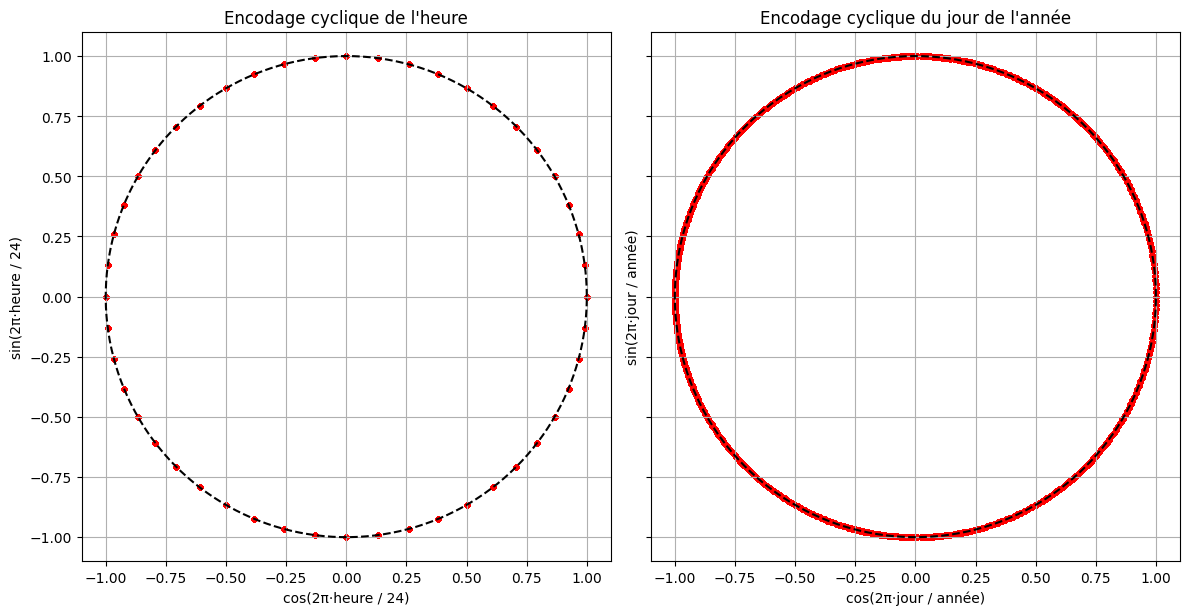

In [5]:
theta = np.linspace(0, 2*np.pi, 360)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# --- Subplot 1 : Encodage cyclique de l'heure ---
ax = axes[0]
ax.scatter(df['cos_hour'], df['sin_hour'], alpha=0.5, s=10, c='red')
ax.plot(np.cos(theta), np.sin(theta), 'k--')  # cercle unité
ax.set_xlabel("cos(2π·heure / 24)")
ax.set_ylabel("sin(2π·heure / 24)")
ax.set_title("Encodage cyclique de l'heure")
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

# --- Subplot 2 : Encodage cyclique du jour de l'année ---
ax = axes[1]
ax.scatter(df['cos_doy'], df['sin_doy'], alpha=0.5, s=10, c='red')
ax.plot(np.cos(theta), np.sin(theta), 'k--')  # cercle unité
ax.set_xlabel("cos(2π·jour / année)")
ax.set_ylabel("sin(2π·jour / année)")
ax.set_title("Encodage cyclique du jour de l'année")
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()
    

Les points rouges sont répartis sur le cercle unité, illustrant le caractère cyclique des variables temporelles : les heures proches de minuit (23 h et 0 h) ainsi que les jours situés aux extrémités de l'année (31 décembre et 1er janvier) restent voisins dans l'espace encodé, contrairement à un encodage linéaire.


## C - Continuité de l'encodage cyclique

Les composantes sinus et cosinus varient de manière continue au cours de la journée.

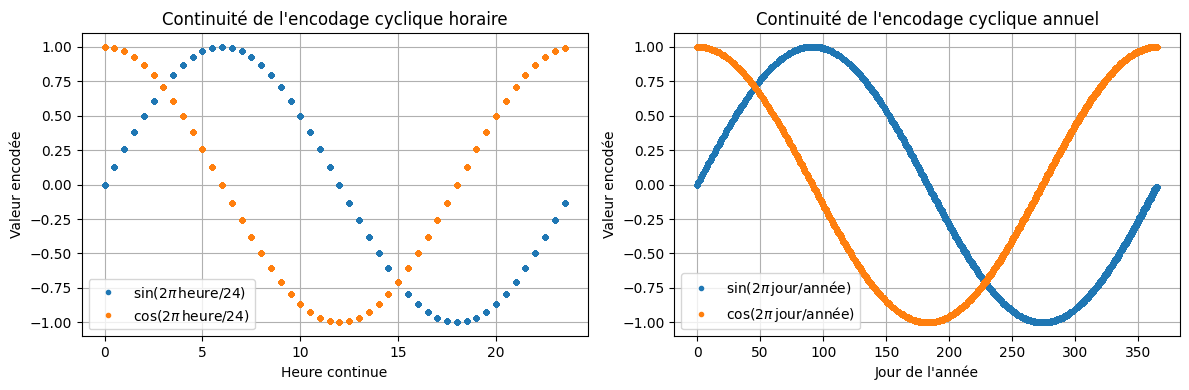

In [6]:
# Encodage cyclique de l'heure (continu, heure + minutes)
hour = df.index.hour + df.index.minute / 60
doy = df.index.dayofyear - 1

plt.figure(figsize=(12, 4))

# --- Plot 1 : Encodage cyclique de l'heure ---
plt.subplot(1, 2, 1)
plt.plot(hour, df['sin_hour'], '.', label=r'$\sin(2\pi\,\mathrm{heure}/24)$')
plt.plot(hour, df['cos_hour'], '.', label=r'$\cos(2\pi\,\mathrm{heure}/24)$')
plt.xlabel("Heure continue")
plt.ylabel("Valeur encodée")
plt.title("Continuité de l'encodage cyclique horaire")
plt.legend()
plt.grid(True)

# --- Plot 2 : Encodage cyclique du jour de l'année ---
plt.subplot(1, 2, 2)
plt.plot(doy, df['sin_doy'], '.', label=r'$\sin(2\pi\,\mathrm{jour}/\mathrm{année})$')
plt.plot(doy, df['cos_doy'], '.', label=r'$\cos(2\pi\,\mathrm{jour}/\mathrm{année})$')
plt.xlabel("Jour de l'année")
plt.ylabel("Valeur encodée")
plt.title("Continuité de l'encodage cyclique annuel")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## D - Continuité autour de minuit et du changement d'année

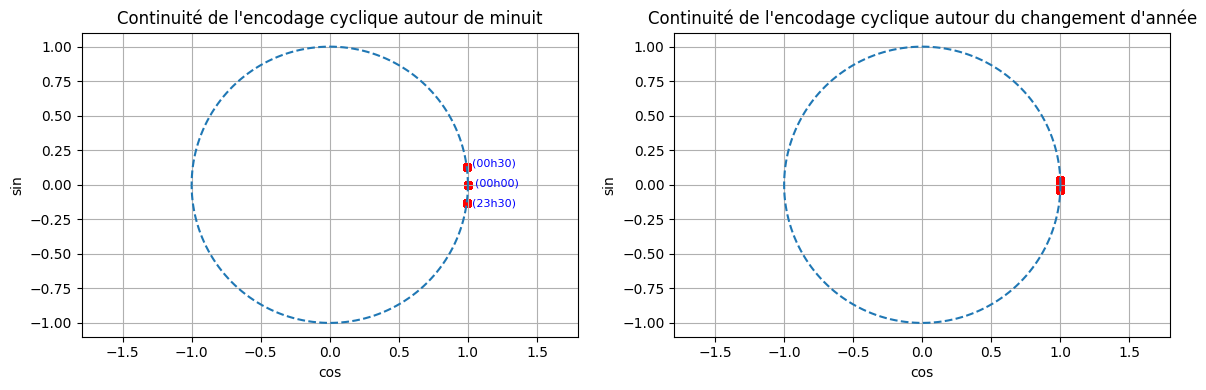

In [7]:
# Encodage cyclique de l'heure (continu, heure + minutes)
hour = df.index.hour + df.index.minute / 60
doy = df.index.dayofyear - 1
year_len = np.where(df.index.is_leap_year, 366, 365)
    
mask_hour = (hour < 1) | (hour > 23)
mask_day  = (doy < 3) | (doy > (year_len - 3))

theta = np.linspace(0, 2*np.pi, 360)

plt.figure(figsize=(12, 4))

# --- Subplot 1 : Continuité autour de minuit ---
plt.subplot(1, 2, 1)
plt.scatter(df.loc[mask_hour, 'cos_hour'],
            df.loc[mask_hour, 'sin_hour'],
            color='red', s=30)

plt.plot(np.cos(theta), np.sin(theta), linestyle='--')
plt.axis('equal')
plt.xlabel("cos")
plt.ylabel("sin")
plt.title("Continuité de l'encodage cyclique autour de minuit")
plt.grid(True)

plt.text(1.05, -0.01, f"(00h00)", fontsize=8, color='blue')
plt.text(1.03, 0.13, f"(00h30)", fontsize=8, color='blue')
plt.text(1.03, -0.16, f"(23h30)", fontsize=8, color='blue')

# --- Subplot 2 : Continuité autour du changement d'année ---
plt.subplot(1, 2, 2)
plt.scatter(df.loc[mask_day, 'cos_doy'],
            df.loc[mask_day, 'sin_doy'],
            color='red', s=30)

plt.plot(np.cos(theta), np.sin(theta), linestyle='--')
plt.axis('equal')
plt.xlabel("cos")
plt.ylabel("sin")
plt.title("Continuité de l'encodage cyclique autour du changement d'année")
plt.grid(True)

plt.tight_layout()
plt.show()

L'utilisation d'un encodage cyclique basé sur les fonctions sinus et cosinus permet de préserver la continuité temporelle de l'heure, notamment autour de la transition minuit, contrairement à un encodage linéaire classique.


# III - Division du jeu de données en train - valid - test

Nous allons maintenant figer les jeux de données d'entrainement, de validation et de test comme suit :


| Période         | Rôle       |
| :-------------- | :--------- |
| 2020–2023       | train      |
| 2024            | validation |
| 2025            | test       |



In [8]:
train = df['2019-12-31':'2023-12-31']
display(train)
train.to_csv(output_path / 'train.csv')

,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,svt_temperature,svt_toa,svt_vitesse_vent,target,tch_solaire,tco_solaire,sin_hour,cos_hour,sin_doy,cos_doy
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,-68.046190,335.241040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.300,0.0,1.190,0.0,0.0,0.0,-0.258819,0.965926,-0.017213,0.999852
2019-12-31 23:30:00+00:00,-69.500739,353.945722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.480,0.0,1.075,0.0,0.0,0.0,-0.130526,0.991445,-0.017213,0.999852
2020-01-01 00:00:00+00:00,-69.141123,13.536657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.660,0.0,0.960,0.0,0.0,0.0,0.000000,1.000000,0.000000,1.000000
2020-01-01 00:30:00+00:00,-67.054165,31.240402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.720,0.0,0.850,0.0,0.0,0.0,0.130526,0.991445,0.000000,1.000000
2020-01-01 01:00:00+00:00,-63.656435,45.699703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.780,0.0,0.740,0.0,0.0,0.0,0.258819,0.965926,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:30:00+00:00,-56.510761,297.029238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.950,0.0,5.100,0.0,0.0,0.0,-0.608761,0.793353,-0.017213,0.999852
2023-12-31 22:00:00+00:00,-61.127320,306.960360,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.630,0.0,5.090,0.0,0.0,0.0,-0.500000,0.866025,-0.017213,0.999852
2023-12-31 22:30:00+00:00,-65.099087,319.480980,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.405,0.0,5.010,0.0,0.0,0.0,-0.382683,0.923880,-0.017213,0.999852


In [9]:
valid = df['2024-01-01':'2024-12-31']
display(valid)
valid.to_csv(output_path / 'valid.csv')

,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,svt_temperature,svt_toa,svt_vitesse_vent,target,tch_solaire,tco_solaire,sin_hour,cos_hour,sin_doy,cos_doy
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,-69.141088,13.532368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.040,0.0,4.960,0.00,0.00,0.00,0.000000,1.000000,0.000000,1.000000
2024-01-01 00:30:00+00:00,-67.054481,31.236592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.060,0.0,4.975,0.00,0.00,0.00,0.130526,0.991445,0.000000,1.000000
2024-01-01 01:00:00+00:00,-63.657001,45.696549,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.080,0.0,4.990,0.00,0.00,0.00,0.258819,0.965926,0.000000,1.000000
2024-01-01 01:30:00+00:00,-59.396982,57.119939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.090,0.0,4.925,0.00,0.00,0.00,0.382683,0.923880,0.000000,1.000000
2024-01-01 02:00:00+00:00,-54.603773,66.256046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.100,0.0,4.860,0.00,0.00,0.00,0.500000,0.866025,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:30:00+00:00,-56.408485,296.995511,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.435,0.0,1.120,0.00,0.00,0.00,-0.608761,0.793353,-0.017166,0.999853
2024-12-31 22:00:00+00:00,-61.027236,306.901701,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.420,0.0,1.090,0.00,0.00,0.00,-0.500000,0.866025,-0.017166,0.999853
2024-12-31 22:30:00+00:00,-65.003985,319.380638,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.415,0.0,1.040,0.04,0.00,0.00,-0.382683,0.923880,-0.017166,0.999853


In [10]:
test = df['2025-01-01':'2025-12-31']
display(test)
test.to_csv(output_path / 'test.csv')

,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,svt_temperature,svt_toa,svt_vitesse_vent,target,tch_solaire,tco_solaire,sin_hour,cos_hour,sin_doy,cos_doy
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,-69.097348,13.266719,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.42,0.0,0.900,0.0,0.0,0.0,0.000000,1.000000,0.000000,1.000000
2025-01-01 00:30:00+00:00,-67.033957,30.974224,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.45,0.0,0.860,0.0,0.0,0.0,0.130526,0.991445,0.000000,1.000000
2025-01-01 01:00:00+00:00,-63.654884,45.461256,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.48,0.0,0.820,0.0,0.0,0.0,0.258819,0.965926,0.000000,1.000000
2025-01-01 01:30:00+00:00,-59.407753,56.915724,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.49,0.0,0.800,0.0,0.0,0.0,0.382683,0.923880,0.000000,1.000000
2025-01-01 02:00:00+00:00,-54.623026,66.078554,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.50,0.0,0.780,0.0,0.0,0.0,0.500000,0.866025,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,-56.569891,297.046679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.11,0.0,6.485,0.0,0.0,0.0,-0.608761,0.793353,-0.034422,0.999407
2025-12-30 22:00:00+00:00,-61.185289,306.991992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.14,0.0,6.680,0.0,0.0,0.0,-0.500000,0.866025,-0.034422,0.999407
2025-12-30 22:30:00+00:00,-65.154326,319.536559,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.23,0.0,6.770,0.0,0.0,0.0,-0.382683,0.923880,-0.034422,0.999407


# IV - Ajout de nouvelles variables explicatives

Aux étapes précédentes, nous avons ajouté notre variable cible, retiré des variables peu significatives et ajouté d'autres, concernant l'**encodage cyclique de la date** (`sin_hour`, `cos_hour`, `sin_doy`, `cos_doy`).

Nous avons maintenant besoin de variables donnant une mémoire à notre jeu de données. On va chercher quelques variables particulièrement significative pour la production d'énergie photovoltaïque et introduire de nouvelles variables dérivées de celles ci.

Parmis les données qu'il pourrait être intéressantes de construire, on trouve :

- les valeurs passées de la variable ;
- la variabilité de la variable au temp t (c'est à dire : $\mathrm{var}(t) - \mathrm{var}(t-\Delta t)$) ;
- les valeurs passées de la variabilité de la variable.


In [11]:
def add_derivate_var(dataset, var) :
    X = dataset.copy()
    
    # Lags
    X[var+'_lag_1'] = X[var].shift(1)
    X[var+'_lag_2'] = X[var].shift(2)
    
    # Variation
    X['d'+var+'_dt'] = X[var].diff()

    # Lags de la variation
    X['d'+var+'_dt_lag_1'] = X['d'+var+'_dt'].shift(1)
    X['d'+var+'_dt_lag_2'] = X['d'+var+'_dt'].shift(2)
    
    return X

On souhaite réaliser des prédictions à 30 minutes : on s'intéresse particulièrement aux évolutions récentes des variables, dans les heures précédentes (par exemple 2h ou 4h).

La moyenne et l'écart type sur les données passées récentes peuvent être intéressants à ajouter à nos variables :

In [12]:
# Nombre de pas de temps correspondant aux fenêtres
window_2h = 4   # 2 heures = 4 pas de 30 minutes
window_4h = 8   # 4 heures = 8 pas de 30 minutes

In [13]:
def add_stats(dataset, var):
    X = dataset.copy()
    
    # Moyennes glissantes
    X[var+'_mean_2h'] = X[var].rolling(window=window_2h).mean()
    X[var+'_mean_4h'] = X[var].rolling(window=window_4h).mean()

    # Ecarts-type glissants
    X[var+'_std_2h'] = X[var].rolling(window=window_2h).std()
    X[var+'_std_4h'] = X[var].rolling(window=window_4h).std()
    
    return X

On crée une liste des jeux de données pour pouvoir les parcourir plus facilement :

In [14]:
all_df = {
    'train': train, 
    'valid': valid, 
    'test': test}

## A - Irradiance solaire

**BNI – Beam (Direct) Normal Irradiance**  
Le $BNI$ correspond au rayonnement solaire direct mesuré sur un plan perpendiculaire aux rayons du soleil.  
Sur un plan horizontal, sa contribution s'écrit :
$$
BHI = BNI \cdot \cos(\theta_z)
$$
où $\theta_z = \dfrac{\pi}{2} - \alpha$ est l'angle zénithal solaire et $\alpha$ l'**altitude solaire**, définie comme l'angle entre le soleil et l'horizon.  
Le $BNI$ dépend donc fortement de la position instantanée du soleil et suppose une orientation optimale du capteur. Or, les panneaux photovoltaïques fixes ne sont pas toujours perpendiculaires aux rayons solaires et ne suivent généralement pas le soleil.

**GHI – Global Horizontal Irradiance**  
Le $GHI$ représente le rayonnement solaire total reçu sur un plan horizontal et s'exprime par :
$$
GHI = BHI + DHI = BNI \cdot \cos(\theta_z) + DHI
$$
où $DHI$ est l'irradiance diffuse horizontale.  
Le $GHI$ intègre ainsi les composantes directe et diffuse du rayonnement et décrit plus fidèlement l'irradiation réellement reçue par les panneaux photovoltaïques standards.

**Choix méthodologique**  
Dans notre projet, nous adoptons le **GHI** comme variable d'entrée principale, car il permet une analyse plus représentative et plus robuste de la variabilité de la production solaire à partir de données ouvertes.

On considère donc les variations temporelles de l'irradiance solaire :

$$
\Delta GHI(t) = GHI(t) - GHI(t-\Delta t)
$$
avec $\Delta t = 30$ minutes.


In [15]:
# Afficher les dimensions des datasets avant
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)

# Récupérer les colonnes à traiter :
cols = []
for col in train.columns:
    if 'ghi' in col:
        if 'clear_sky' not in col:
            cols.append(col)
print(cols)
        
for key in all_df.keys():
    for col in cols:
        all_df[key] = add_derivate_var(all_df[key], col)
        all_df[key] = add_stats(all_df[key], col)

# Afficher le début et la fin du dataset
display(all_df['train'])

# Afficher les dimensions du dataset
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)


Dimensions train/valid/test : (70130, 90) (17568, 90) (17472, 90)
['bra_ghi', 'cru_ghi', 'eyg_ghi', 'sel_ghi', 'svt_ghi']


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,sel_ghi_std_4h,svt_ghi_lag_1,svt_ghi_lag_2,dsvt_ghi_dt,dsvt_ghi_dt_lag_1,dsvt_ghi_dt_lag_2,svt_ghi_mean_2h,svt_ghi_mean_4h,svt_ghi_std_2h,svt_ghi_std_4h
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,-68.046190,335.241040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 23:30:00+00:00,-69.500739,353.945722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 00:00:00+00:00,-69.141123,13.536657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2020-01-01 00:30:00+00:00,-67.054165,31.240402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN
2020-01-01 01:00:00+00:00,-63.656435,45.699703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:30:00+00:00,-56.510761,297.029238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 22:00:00+00:00,-61.127320,306.960360,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 22:30:00+00:00,-65.099087,319.480980,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Dimensions train/valid/test : (70130, 135) (17568, 135) (17472, 135)


## B - Nébulosité

Les rampes de production photovoltaïque sont principalement déclenchées par des variations rapides de l'irradiance solaire, généralement associées aux passages nuageux.

On considère donc les variations temporelles de la nébulosité :

$$
\Delta \text{Nebulosite}(t) =
\text{Nebulosite}(t) -
\text{Nebulosite}(t-\Delta t)
$$
avec $\Delta t = 30$ minutes.

Ces variables capturent directement les transitions nuageuses responsables des rampes de production photovoltaïque.


In [16]:
# Afficher les dimensions des datasets avant
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)

# Récupérer les colonnes à traiter :
cols = []
for col in train.columns:
    if 'nebulosite' in col:
            cols.append(col)
print(cols)
        
for key in all_df.keys():
    for col in cols:
        all_df[key] = add_derivate_var(all_df[key], col)

# Afficher le début et la fin du dataset
display(all_df['train'])

# Afficher les dimensions du dataset
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)


Dimensions train/valid/test : (70130, 135) (17568, 135) (17472, 135)
['bra_nebulosite', 'cru_nebulosite', 'eyg_nebulosite', 'sel_nebulosite', 'svt_nebulosite']


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,sel_nebulosite_lag_1,sel_nebulosite_lag_2,dsel_nebulosite_dt,dsel_nebulosite_dt_lag_1,dsel_nebulosite_dt_lag_2,svt_nebulosite_lag_1,svt_nebulosite_lag_2,dsvt_nebulosite_dt,dsvt_nebulosite_dt_lag_1,dsvt_nebulosite_dt_lag_2
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,-68.046190,335.241040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 23:30:00+00:00,-69.500739,353.945722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.680,NaN,3.295,NaN,NaN,29.440,NaN,-4.655,NaN,NaN
2020-01-01 00:00:00+00:00,-69.141123,13.536657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,25.975,22.680,3.295,3.295,NaN,24.785,29.440,-4.655,-4.655,NaN
2020-01-01 00:30:00+00:00,-67.054165,31.240402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,29.270,25.975,-11.790,3.295,3.295,20.130,24.785,-9.790,-4.655,-4.655
2020-01-01 01:00:00+00:00,-63.656435,45.699703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17.480,29.270,-11.790,-11.790,3.295,10.340,20.130,-9.790,-9.790,-4.655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:30:00+00:00,-56.510761,297.029238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.510,58.205,-4.810,-0.695,-0.695,29.770,24.190,11.150,5.580,5.580
2023-12-31 22:00:00+00:00,-61.127320,306.960360,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,52.700,57.510,-4.810,-4.810,-0.695,40.920,29.770,11.150,11.150,5.580
2023-12-31 22:30:00+00:00,-65.099087,319.480980,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,47.890,52.700,-3.955,-4.810,-4.810,52.070,40.920,15.905,11.150,11.150


Dimensions train/valid/test : (70130, 160) (17568, 160) (17472, 160)


## C - Production d'énergie

On considère également la production des panneaux photovoltaïques au cours des heures précédentes, ainsi que les valeurs précédentes de notre variable cible.

In [17]:
# Afficher les dimensions des datasets avant
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)

for key in all_df.keys():
    all_df[key] = add_derivate_var(all_df[key], 'tch_solaire')
    all_df[key]['target_lag_1'] = all_df[key]['target'].shift(1)
    all_df[key]['target_lag_2'] = all_df[key]['target'].shift(2)

# Afficher une partie du dataset
display(all_df['train'].iloc[25:30])

# Afficher les dimensions du dataset
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)


Dimensions train/valid/test : (70130, 160) (17568, 160) (17472, 160)


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,dsvt_nebulosite_dt,dsvt_nebulosite_dt_lag_1,dsvt_nebulosite_dt_lag_2,tch_solaire_lag_1,tch_solaire_lag_2,dtch_solaire_dt,dtch_solaire_dt_lag_1,dtch_solaire_dt_lag_2,target_lag_1,target_lag_2
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 11:30:00+00:00,23.506839,177.632292,162.7169,409.0287,175.5767,441.4038,30.2689,205.8457,35.9292,198.6463,...,-0.615,-0.615,-0.615,47.47,43.74,2.08,3.73,5.59,2.08,3.73
2020-01-01 12:00:00+00:00,23.376558,185.150177,174.3342,440.5697,174.3342,440.5697,30.2333,204.5675,30.2333,204.5675,...,-0.615,-0.615,-0.615,49.55,47.47,0.15,2.08,3.73,0.15,2.08
2020-01-01 12:30:00+00:00,22.540426,192.586999,166.4669,435.4517,166.4669,435.4517,29.8626,196.3296,29.8626,196.3296,...,2.025,-0.615,-0.615,49.70,49.55,-1.26,0.15,2.08,1.26,0.15
2020-01-01 13:00:00+00:00,21.025371,199.834374,152.3096,425.7368,152.3096,425.7368,29.0730,181.3825,29.0730,181.3825,...,2.025,2.025,-0.615,48.44,49.70,-2.76,-1.26,0.15,2.76,1.26
2020-01-01 13:30:00+00:00,18.877189,206.807477,132.3533,410.3418,132.3533,410.3418,27.7822,160.1355,27.7822,160.1355,...,1.015,2.025,2.025,45.68,48.44,-5.14,-2.76,-1.26,5.14,2.76


Dimensions train/valid/test : (70130, 167) (17568, 167) (17472, 167)


# V - Supression des valeurs nulles

La création des nouvelles variables a introduit des valeurs nulles dans les jeux de données : on supprime les lignes correspondantes.

In [18]:
for key in all_df.keys():
    all_df[key] = all_df[key].dropna()
    
# Afficher le début d'un dataset
display(all_df['train'].head())

# Afficher les dimensions des datasets
print('Dimensions train/valid/test :', all_df['train'].shape, all_df['valid'].shape, all_df['test'].shape)


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,dsvt_nebulosite_dt,dsvt_nebulosite_dt_lag_1,dsvt_nebulosite_dt_lag_2,tch_solaire_lag_1,tch_solaire_lag_2,dtch_solaire_dt,dtch_solaire_dt_lag_1,dtch_solaire_dt_lag_2,target_lag_1,target_lag_2
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 02:30:00+00:00,-49.488368,73.801849,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.545,-0.130,-0.130,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 03:00:00+00:00,-44.186485,80.264541,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.545,9.545,-0.130,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 03:30:00+00:00,-38.785359,86.000566,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.365,9.545,9.545,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 04:00:00+00:00,-33.346881,91.256074,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.365,0.365,9.545,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 04:30:00+00:00,-27.918331,96.207025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.800,0.365,0.365,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Dimensions train/valid/test : (70123, 167) (17561, 167) (17465, 167)


# VI - Sauvegarde des jeux de données entiers sur 5 points

On commence par trier les colonnes par ordre alphabétique pour pouvoir ensuite les retrouver plus facilement pour un opérateur humain :

In [19]:
for key in all_df.keys():
    all_df[key] = all_df[key].sort_index(axis=1)
    
# Afficher le début d'un dataset
display(all_df['train'].head())

,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,svt_temperature,svt_toa,svt_vitesse_vent,target,target_lag_1,target_lag_2,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 02:30:00+00:00,-49.488368,73.801849,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.740,0.0,0.830,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 03:00:00+00:00,-44.186485,80.264541,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.650,0.0,0.870,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 03:30:00+00:00,-38.785359,86.000566,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.545,0.0,0.850,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 04:00:00+00:00,-33.346881,91.256074,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.440,0.0,0.830,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 04:30:00+00:00,-27.918331,96.207025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.440,0.0,0.805,0.0,0.0,0.0,0.0,0.0,0.0,0.0


On sauvegarde les jeux de données train, valid et test :

In [20]:
all_df['train'].to_csv(output_path / 'train_5pts_tot.csv')
all_df['valid'].to_csv(output_path / 'valid_5pts_tot.csv')
all_df['test'].to_csv(output_path / 'test_5pts_tot.csv')


# VII - Aggrégation au niveau régional

Comme vu dans les notebooks d'exploration précédents, il se pourrait qu'aggréger les variables obtenues aux 5 points d'intérêts régionaux facilite la modélisation.

Nous allons donc créer une nouvelle version de nos jeux de données dans laquelle les variables communales sont aggrégées en une variable régionale.


In [36]:
# Créer un dictionnaire des variables disponibles pour chaque commune
for ville in villes:
    dico_corresp[ville] = []
    
    for var in var_5pts:    
        base_name = f'{ville}_{var}'
        
        for col in all_df['train'].columns:
            if base_name in col:
                dico_corresp[ville].append(col)

# Nouveau nom de colonne pour la région
dico_corresp['region'] = []
for col in dico_corresp['bra']:
    dico_corresp['region'].append(col.replace('bra_', ''))
                
# Affichage du résultat
for ville in dico_corresp:
    print(f"\n{ville} ({len(dico_corresp[ville])}) :")
    print(dico_corresp[ville])



cru (30) :
['cru_altitude', 'cru_azimuth', 'cru_bhi', 'cru_bni', 'cru_clear_sky_bhi', 'cru_clear_sky_bni', 'cru_clear_sky_dhi', 'cru_clear_sky_ghi', 'cru_dhi', 'cru_ghi', 'cru_ghi_lag_1', 'cru_ghi_lag_2', 'cru_ghi_mean_2h', 'cru_ghi_mean_4h', 'cru_ghi_std_2h', 'cru_ghi_std_4h', 'dcru_ghi_dt', 'dcru_ghi_dt_lag_1', 'dcru_ghi_dt_lag_2', 'cru_humidite', 'cru_nebulosite', 'cru_nebulosite_lag_1', 'cru_nebulosite_lag_2', 'dcru_nebulosite_dt', 'dcru_nebulosite_dt_lag_1', 'dcru_nebulosite_dt_lag_2', 'cru_reliability', 'cru_temperature', 'cru_toa', 'cru_vitesse_vent']

sel (30) :
['sel_altitude', 'sel_azimuth', 'sel_bhi', 'sel_bni', 'sel_clear_sky_bhi', 'sel_clear_sky_bni', 'sel_clear_sky_dhi', 'sel_clear_sky_ghi', 'sel_dhi', 'dsel_ghi_dt', 'dsel_ghi_dt_lag_1', 'dsel_ghi_dt_lag_2', 'sel_ghi', 'sel_ghi_lag_1', 'sel_ghi_lag_2', 'sel_ghi_mean_2h', 'sel_ghi_mean_4h', 'sel_ghi_std_2h', 'sel_ghi_std_4h', 'sel_humidite', 'dsel_nebulosite_dt', 'dsel_nebulosite_dt_lag_1', 'dsel_nebulosite_dt_lag_2', 'se

In [48]:
def to_region(dataset): # Regroupement des colonnes
        """ Regroupe les variables concernant les communes """
        
        data = dataset.copy()
        poids = list(df_communes['poids'])
        
        nb_variables = len(dico_corresp['region'])
        
        for i in range(nb_variables):
            # Récupération du nom à prendre pour la variable régionale
            col_region = dico_corresp['region'][i]
            # La somme pondérée est initialisée à 0
            data[col_region] = 0.0 
            
            # Calcul
            for p, ville in zip(poids, villes):
                # Récupération du nom à prendre pour la variable communale
                col_ville = dico_corresp[ville][i]
                # Calcul de la somme pondérée
                data[col_region] = data[col_region] + p * data[col_ville]

        # Supression des colonnes devenues inutiles
        cols_to_drop = []
        for ville, cols in dico_corresp.items():
            if 'region' not in ville:
                cols_to_drop.extend(cols)
        
        return data.drop(cols_to_drop, axis=1)


In [54]:
for key in ['train', 'valid', 'test']:
    all_df['region_'+key] = to_region(all_df[key])
    all_df['region_'+key] = all_df['region_'+key].sort_index(axis=1)
    all_df['region_'+key].to_csv(key+'_region_tot.csv')


In [55]:
for key, df in all_df.items():
    print(f"{key} {df.shape} :")
    display(df.head())
    

train (70123, 167) :


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,svt_temperature,svt_toa,svt_vitesse_vent,target,target_lag_1,target_lag_2,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 02:30:00+00:00,-49.488368,73.801849,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.740,0.0,0.830,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 03:00:00+00:00,-44.186485,80.264541,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.650,0.0,0.870,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 03:30:00+00:00,-38.785359,86.000566,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.545,0.0,0.850,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 04:00:00+00:00,-33.346881,91.256074,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.440,0.0,0.830,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 04:30:00+00:00,-27.918331,96.207025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.440,0.0,0.805,0.0,0.0,0.0,0.0,0.0,0.0,0.0


valid (17561, 167) :


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,svt_temperature,svt_toa,svt_vitesse_vent,target,target_lag_1,target_lag_2,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2024-01-01 03:30:00+00:00,-38.786269,85.999092,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.120,0.0,4.680,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 04:00:00+00:00,-33.347785,91.254706,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.130,0.0,4.620,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 04:30:00+00:00,-27.919217,96.205727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.150,0.0,4.570,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 05:00:00+00:00,-22.540072,100.983272,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.170,0.0,4.520,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 05:30:00+00:00,-17.246352,105.689845,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.215,0.0,4.485,0.0,0.0,0.0,0.0,0.0,0.0,0.0


test (17465, 167) :


...

,altitude,azimuth,bhi,bni,clear_sky_bhi,clear_sky_bni,clear_sky_dhi,clear_sky_ghi,consommation,cos_doy,...,target,target_lag_1,target_lag_2,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tco_solaire,temperature,toa,vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 02:30:00+00:00,-49.612365,73.153022,0.0,0.0,0.0,0.0,0.0,0.0,5433.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.51620,0.0,1.04585
2020-01-01 03:00:00+00:00,-44.351772,79.705519,0.0,0.0,0.0,0.0,0.0,0.0,5332.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.36130,0.0,0.96980
2020-01-01 03:30:00+00:00,-38.985473,85.516174,0.0,0.0,0.0,0.0,0.0,0.0,5219.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.26355,0.0,0.97035
2020-01-01 04:00:00+00:00,-33.577090,90.833727,0.0,0.0,0.0,0.0,0.0,0.0,5157.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.16580,0.0,0.97090
2020-01-01 04:30:00+00:00,-28.175070,95.836426,0.0,0.0,0.0,0.0,0.0,0.0,5161.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.22595,0.0,0.98650


region_valid (17561, 47) :


,altitude,azimuth,bhi,bni,clear_sky_bhi,clear_sky_bni,clear_sky_dhi,clear_sky_ghi,consommation,cos_doy,...,target,target_lag_1,target_lag_2,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tco_solaire,temperature,toa,vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2024-01-01 03:30:00+00:00,-38.986375,85.514687,0.0,0.0,0.0,0.0,0.0,0.0,4437.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.37070,0.0,2.14610
2024-01-01 04:00:00+00:00,-33.577986,90.832347,0.0,0.0,0.0,0.0,0.0,0.0,4358.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.35670,0.0,2.07960
2024-01-01 04:30:00+00:00,-28.175949,95.835120,0.0,0.0,0.0,0.0,0.0,0.0,4359.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.35455,0.0,2.04680
2024-01-01 05:00:00+00:00,-22.820547,100.655881,0.0,0.0,0.0,0.0,0.0,0.0,4302.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.35240,0.0,2.01400
2024-01-01 05:30:00+00:00,-17.548276,105.398388,0.0,0.0,0.0,0.0,0.0,0.0,4305.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.36950,0.0,2.00845


region_test (17465, 47) :


,altitude,azimuth,bhi,bni,clear_sky_bhi,clear_sky_bni,clear_sky_dhi,clear_sky_ghi,consommation,cos_doy,...,target,target_lag_1,target_lag_2,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tco_solaire,temperature,toa,vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2025-01-01 03:30:00+00:00,-39.014744,85.384895,0.0,0.0,0.0,0.0,0.0,0.0,4938.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.48685,0.0,0.82015
2025-01-01 04:00:00+00:00,-33.606663,90.711278,0.0,0.0,0.0,0.0,0.0,0.0,4860.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.44950,0.0,0.82530
2025-01-01 04:30:00+00:00,-28.203910,95.720390,0.0,0.0,0.0,0.0,0.0,0.0,4861.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.40500,0.0,0.83875
2025-01-01 05:00:00+00:00,-22.846916,100.545622,0.0,0.0,0.0,0.0,0.0,0.0,4807.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.36050,0.0,0.85220
2025-01-01 05:30:00+00:00,-17.572258,105.291110,0.0,0.0,0.0,0.0,0.0,0.0,4805.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.29580,0.0,0.86105


# VIII - Supression de variables

# IX - Analyse de la pertinence des variables ajoutées

In [22]:
import statsmodels.api as sm

def see_backward_elimination(dataset, target_name='target', train_end='2023-12-31'):
    
    dataset_train = all_df['train'].copy()
    dataset_train = dataset_train.drop('signed_var_tch_tp30', axis=1)
    
    scaler = StandardScaler()
    df_train_scaled = pd.DataFrame(
        scaler.fit_transform(dataset_train), 
        columns=dataset_train.columns)

    X_train = df_train_scaled.drop('target', axis=1)
    y_train = df_train_scaled['target']

    X_train_be = sm.add_constant(X_train)  # Ajoute l’intercept (constante)
    model_be = sm.OLS(y_train, X_train_be).fit()

    print("\n [Backward Elimination - p-values]")
    print(model_be.summary())

    # On sélectionne uniquement les variables avec p-value < 0.05
    selected_features = model_be.pvalues[model_be.pvalues < 0.05].index.tolist()
    selected_features = [f for f in selected_features if f != 'const']  # On enlève l'intercept
    # On affiche les variables retenues
    print(f"\nVariables retenues ({len(selected_features)}) :")
    for col in selected_features :
        print(f'\t{col}')
        
    # On cherche quelles variables ont été rejetées
    rejected_features = [col for col in dataset_train.columns if col not in selected_features]
    rejected_features.remove('target')
    print(f"\nVariables rejetées ({len(rejected_features)}) :")
    for col in rejected_features :
        print(f'\t{col}')



In [23]:
see_backward_elimination(df)


 [Backward Elimination - p-values]
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.877
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     3622.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        13:49:55   Log-Likelihood:                -25976.
No. Observations:               70123   AIC:                         5.223e+04
Df Residuals:                   69984   BIC:                         5.350e+04
Df Model:                         138                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [18]:
def get_correlated_columns(df, threshold=0.8):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    # Garder une colonne par paire corrélée
    to_drop = [col for col in upper.columns if any(upper[col] >= threshold)]
    return to_drop

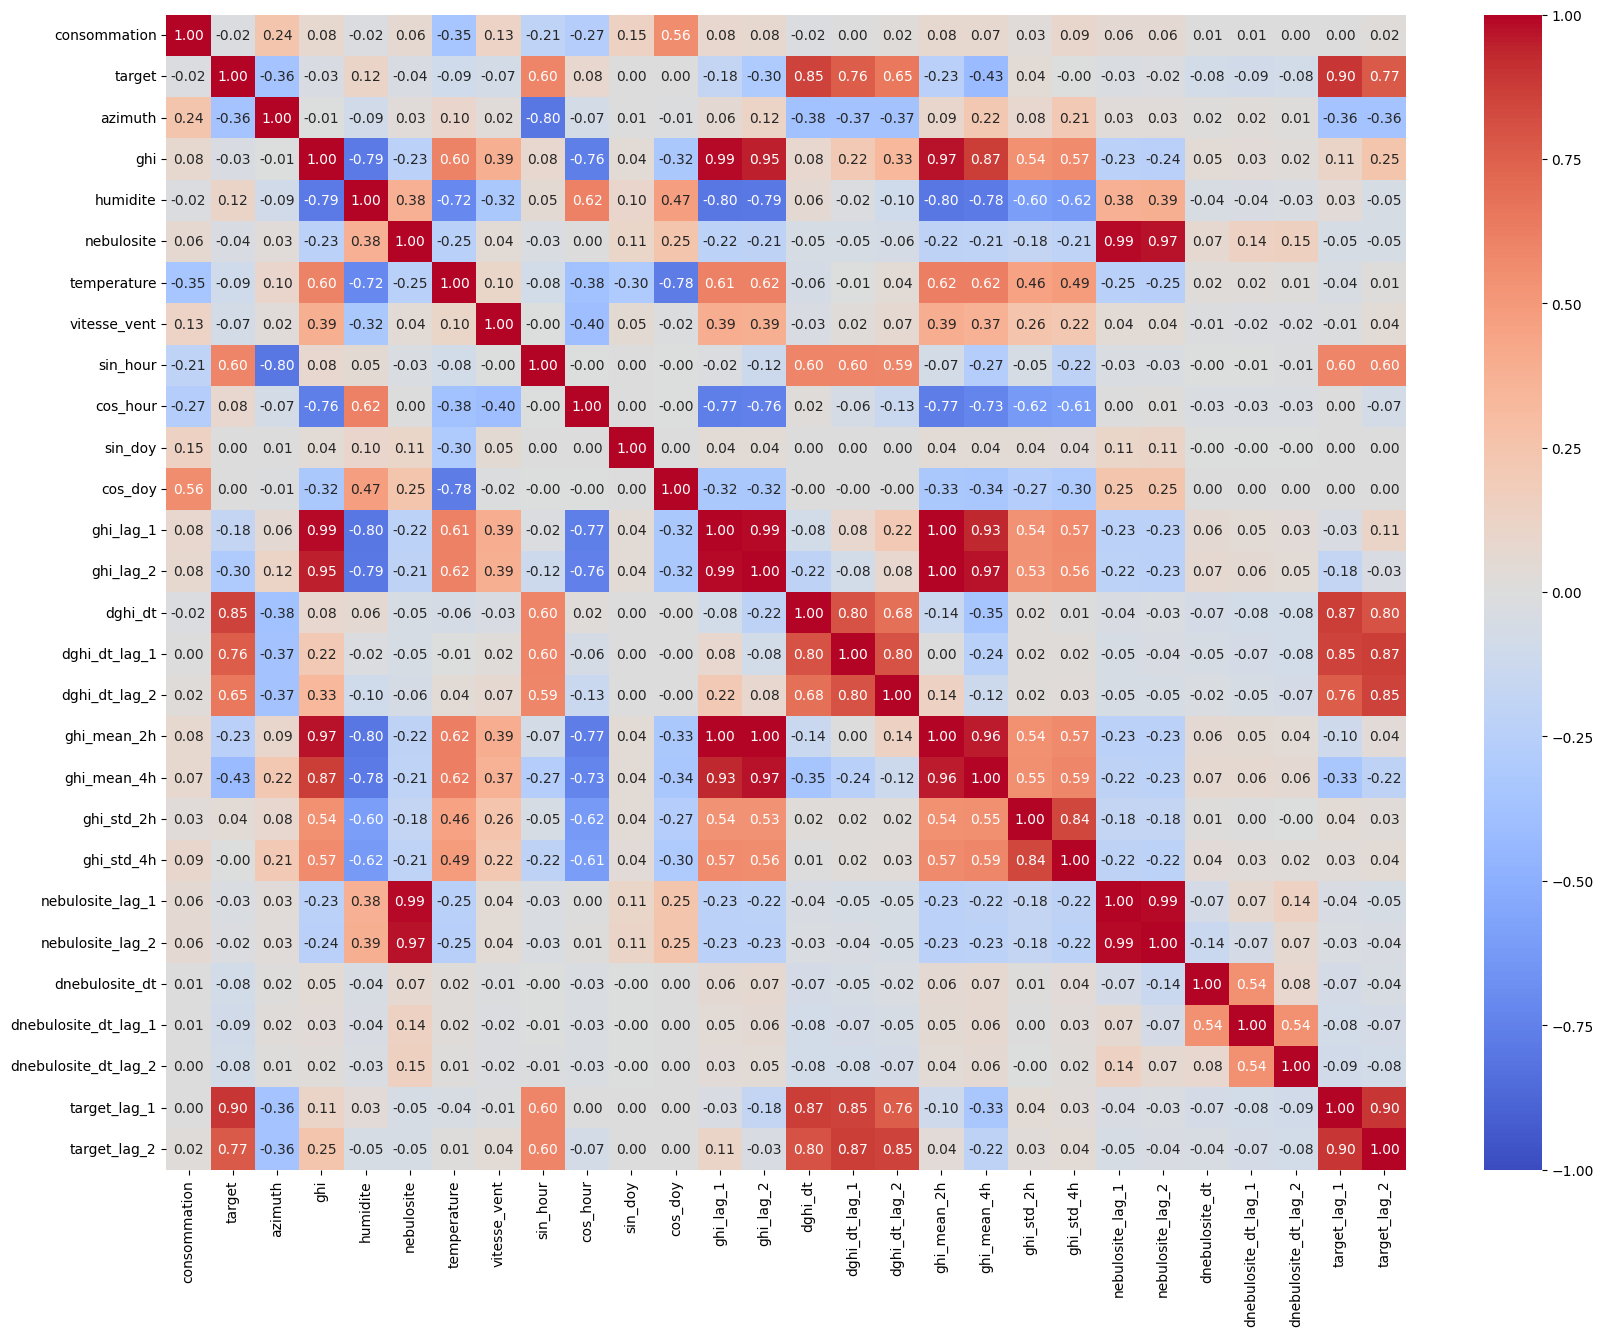

Variables avec au moins une corrélation supérieure à 80% : ['sin_hour', 'ghi_lag_1', 'ghi_lag_2', 'dghi_dt', 'ghi_mean_2h', 'ghi_mean_4h', 'ghi_std_4h', 'nebulosite_lag_1', 'nebulosite_lag_2', 'target_lag_1', 'target_lag_2']


In [19]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1.0, vmax=1.0)
plt.show()

print("Variables avec au moins une corrélation supérieure à 80% :", get_correlated_columns(df, threshold=0.8))



 [Backward Elimination - p-values]
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                 1.780e+04
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        16:56:29   Log-Likelihood:                -42640.
No. Observations:               70123   AIC:                         8.531e+04
Df Residuals:                   70106   BIC:                         8.547e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

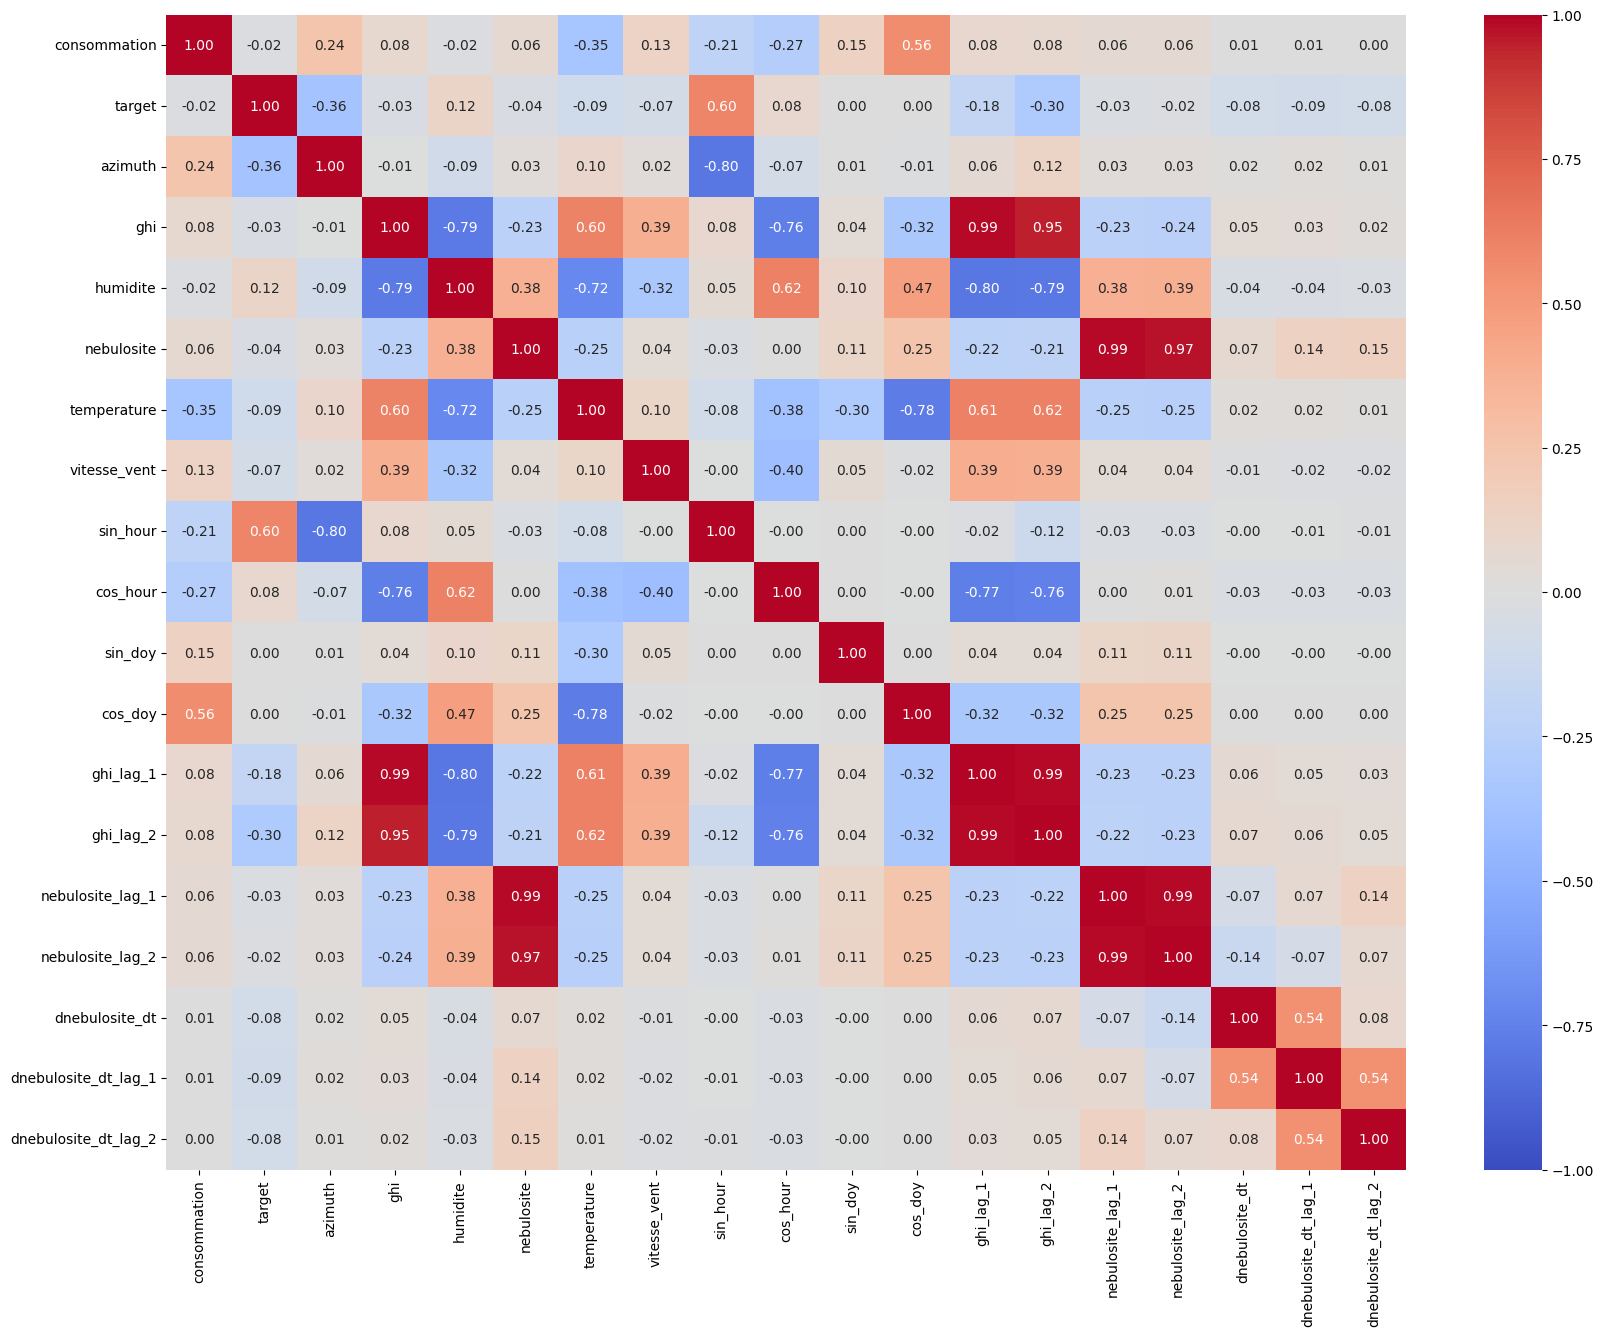

Variables avec au moins une corrélation supérieure à 80% : ['sin_hour', 'ghi_lag_1', 'ghi_lag_2', 'dghi_dt', 'ghi_mean_2h', 'ghi_mean_4h', 'ghi_std_4h', 'nebulosite_lag_1', 'nebulosite_lag_2', 'target_lag_1', 'target_lag_2']


In [20]:
df_test = df.drop(['ghi_mean_2h', 'ghi_mean_4h', 'ghi_std_2h', 'ghi_std_4h', 
                   'target_lag_1', 'target_lag_2', 'dghi_dt', 'dghi_dt_lag_1', 'dghi_dt_lag_2'], axis=1)

see_backward_elimination(df_test)

plt.figure(figsize=(20, 15))
sns.heatmap(df_test.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1.0, vmax=1.0)
plt.show()

print("Variables avec au moins une corrélation supérieure à 80% :", get_correlated_columns(df, threshold=0.8))
